In [1]:
    """
    This file plots G6sulfur-SSP245 precipitation change as a percentage change of mean HIST.
    All values are ensemble mean
    """

'\nThis file plots G6sulfur-SSP245 precipitation change as a percentage change of mean HIST.\nAll values are ensemble mean\n'

In [2]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
pr_clim=xr.open_dataset('/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Climatology.nc')

In [4]:
print("pr_clim",pr_clim)

pr_clim <xarray.Dataset> Size: 2MB
Dimensions:     (model: 5, experiment: 5, season: 3, lat: 41, lon: 144)
Coordinates:
  * model       (model) <U13 260B 'UKESM1-0-LL' 'CNRM-ESM2-1' ... 'IPSL-CM6A-LR'
  * experiment  (experiment) <U8 160B 'HIST' 'SSP245' ... 'G6solar' 'G6sulfur'
  * lat         (lat) float64 328B -50.0 -47.5 -45.0 -42.5 ... 45.0 47.5 50.0
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * season      (season) <U4 48B 'JJAS' 'NDJF' 'ANN'
Data variables:
    pr          (model, experiment, season, lat, lon) float32 2MB ...


In [5]:
def plot_precip_pct_change(
    pr_clim,
    EXP_minuend,
    EXP_subtrahend,
    EXP_base,
    factor=86400
):
    import numpy as np
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from matplotlib.colors import BoundaryNorm
    import xarray as xr

    # ================================================================
    # 1) CALCULATE PERCENTAGE CHANGE
    # ================================================================

    hist_clim = pr_clim.sel(experiment=EXP_base)['pr'].mean(dim='model') * factor

    delta_pr_jjas = pr_clim.sel(season='JJAS', experiment=EXP_minuend)['pr'].mean(dim='model') * factor \
                    - pr_clim.sel(season='JJAS', experiment=EXP_subtrahend)['pr'].mean(dim='model') * factor

    delta_pr_ndjf = pr_clim.sel(season='NDJF', experiment=EXP_minuend)['pr'].mean(dim='model') * factor \
                    - pr_clim.sel(season='NDJF', experiment=EXP_subtrahend)['pr'].mean(dim='model') * factor

    pct_change_jjas = (delta_pr_jjas / hist_clim.sel(season='JJAS')) * 100
    pct_change_ndjf = (delta_pr_ndjf / hist_clim.sel(season='NDJF')) * 100

    # ================================================================
    # 2) STITCH HEMISPHERES
    # ================================================================

    pct_change_stitched = xr.where(
        pct_change_jjas.lat >= 0,
        pct_change_jjas,
        pct_change_ndjf
    )

    # ================================================================
    # 3) MODEL AGREEMENT
    # ================================================================

    delta_pr_jjas_models = pr_clim.sel(season='JJAS', experiment=EXP_minuend)['pr'] * factor \
                          - pr_clim.sel(season='JJAS', experiment=EXP_subtrahend)['pr'] * factor

    delta_pr_ndjf_models = pr_clim.sel(season='NDJF', experiment=EXP_minuend)['pr'] * factor \
                          - pr_clim.sel(season='NDJF', experiment=EXP_subtrahend)['pr'] * factor

    hist_clim_jjas_models = pr_clim.sel(experiment=EXP_base, season='JJAS')['pr'] * factor
    hist_clim_ndjf_models = pr_clim.sel(experiment=EXP_base, season='NDJF')['pr'] * factor

    pct_jjas_models = (delta_pr_jjas_models / hist_clim_jjas_models) * 100
    pct_ndjf_models = (delta_pr_ndjf_models / hist_clim_ndjf_models) * 100

    stitched_models = []
    for model in pct_jjas_models.model:
        stitched = xr.where(
            pct_jjas_models.lat >= 0,
            pct_jjas_models.sel(model=model),
            pct_ndjf_models.sel(model=model)
        )
        stitched_models.append(stitched)

    stitched_models = xr.concat(stitched_models, dim='model')

    sign_ensemble = np.sign(pct_change_stitched)
    sign_models = np.sign(stitched_models)

    agreement = (sign_models == sign_ensemble).sum(dim='model') / len(stitched_models.model)
    stipple_mask = agreement >= 0.8

    # print(f"DEBUG: Agreement stats:")
    # print(f"  Min agreement: {float(agreement.min()):.2f}")
    # print(f"  Max agreement: {float(agreement.max()):.2f}")
    # print(f"  Mean agreement: {float(agreement.mean()):.2f}")
    # print(f"  Fraction with >=80% agreement: {float(stipple_mask.mean()):.2%}")

    # ================================================================
    # 4) PLOTTING
    # ================================================================

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=0))

    levels = np.array([-50, -40, -30, -20, -10, -5, 0, 5, 10, 20, 30, 40, 50])
    cmap = plt.cm.PiYG
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    im = ax.pcolormesh(
        pct_change_stitched.lon,
        pct_change_stitched.lat,
        pct_change_stitched,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading='auto'
    )

    # Zero contour
    ax.contour(
        pct_change_stitched.lon,
        pct_change_stitched.lat,
        pct_change_stitched,
        levels=[0],
        colors='lightgreen',
        linewidths=1.0,
        transform=ccrs.PlateCarree()
    )

    # Stippling (hatching)
    stipple_data = xr.where(stipple_mask, 1, np.nan)
    ax.contourf(
        stipple_mask.lon,
        stipple_mask.lat,
        stipple_data,
        levels=[0.5, 1.5],
        hatches=['...'],
        colors='none',
        transform=ccrs.PlateCarree()
    )

    # Scatter stippling
    lon_mesh, lat_mesh = np.meshgrid(pct_change_stitched.lon, pct_change_stitched.lat)
    stipple_points = stipple_mask.values

    subsample = 2
    lon_subset = lon_mesh[::subsample, ::subsample][stipple_points[::subsample, ::subsample]]
    lat_subset = lat_mesh[::subsample, ::subsample][stipple_points[::subsample, ::subsample]]

    # print(f"DEBUG: Plotting {len(lon_subset)} stipple points")

    ax.plot(
        lon_subset,
        lat_subset,
        'k.',
        markersize=2,
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        markeredgewidth=0,
        zorder=3
    )

    ax.coastlines(linewidth=2.0, color='k', zorder=4)
    # ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5, zorder=4)

    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.3, linestyle='--')

    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,
                        shrink=0.7, aspect=30, extend='both')
    cbar.set_label(f'Precipitation change (% of {EXP_base})', fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    ax.set_title(
        f'{EXP_minuend} - {EXP_subtrahend} Precipitation Change (% of {EXP_base})\n'
        'JJAS (NH) / NDJF (SH) | Stippling: ≥80% model agreement on sign',
        fontsize=13,
        pad=10
    )

    plt.tight_layout()
    plt.show()

    # print(f"✓ Plot created")
    # print(f"  Percentage change range: {float(pct_change_stitched.min()):.1f}% to {float(pct_change_stitched.max()):.1f}%")
    # print(f"  Model agreement fraction: {float(agreement.min()):.2f} to {float(agreement.max()):.2f}")
    # print(f"  Stippled area: {float(stipple_mask.mean())*100:.1f}% of domain")

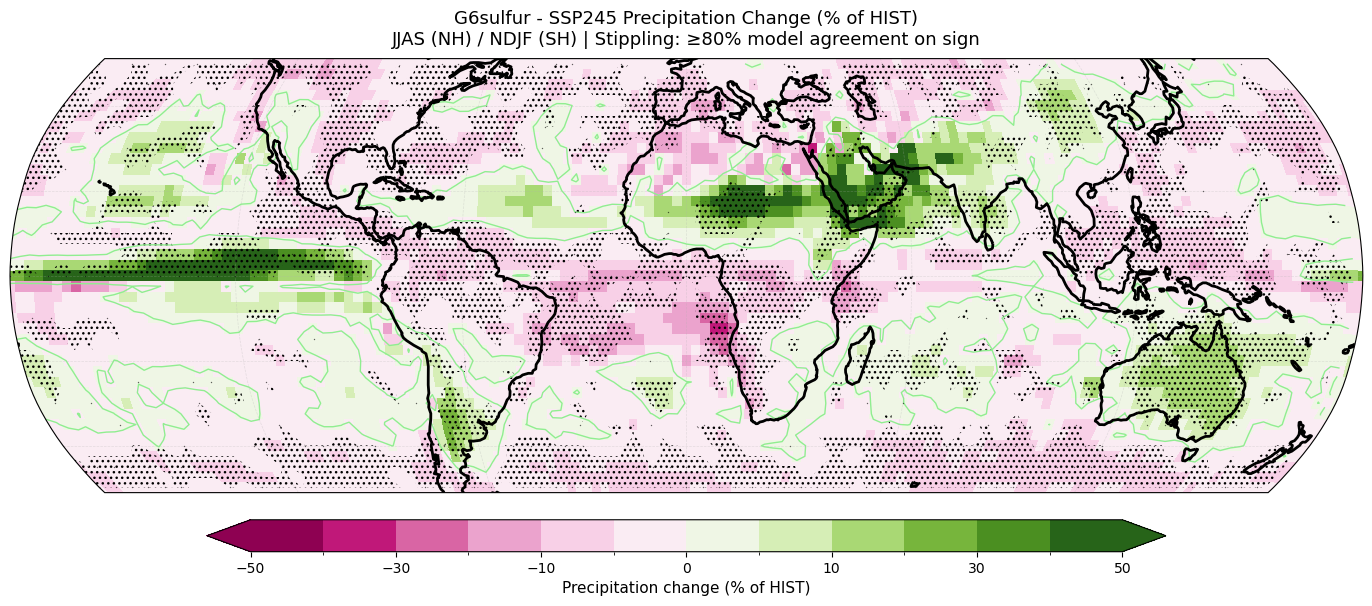

In [6]:
plot_precip_pct_change(
    pr_clim,
    EXP_minuend='G6sulfur',
    EXP_subtrahend='SSP245',
    EXP_base='HIST'
)

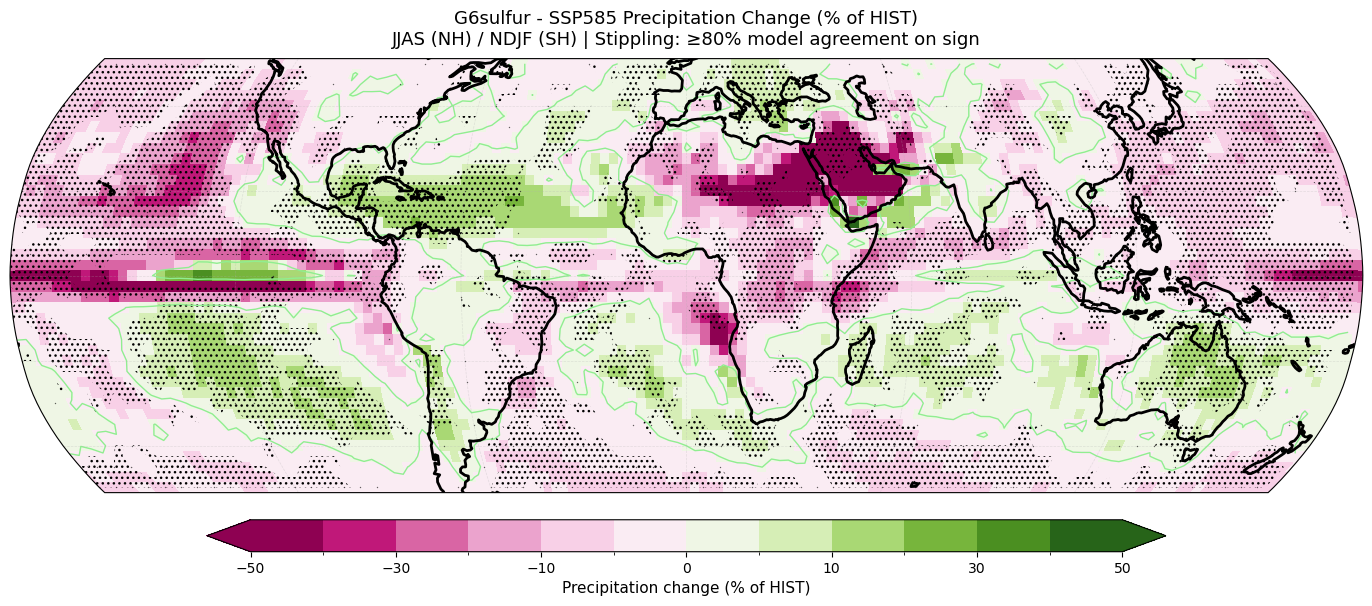

In [7]:
plot_precip_pct_change(
    pr_clim,
    EXP_minuend='G6sulfur',
    EXP_subtrahend='SSP585',
    EXP_base='HIST'
)

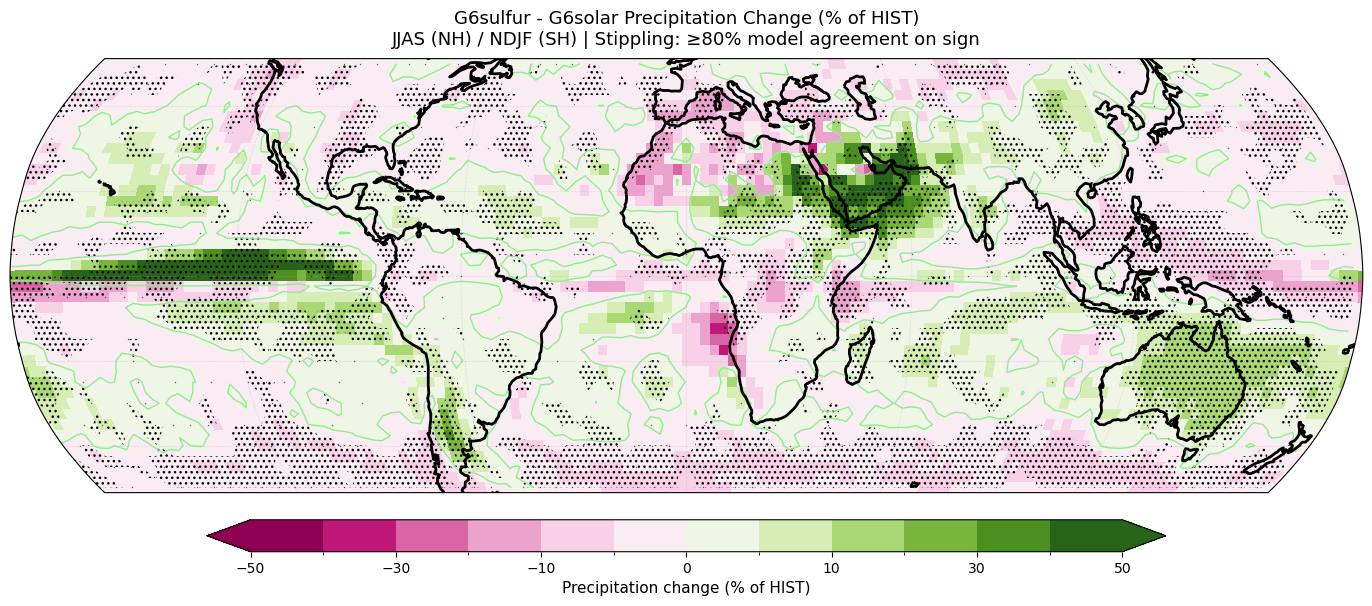

In [8]:
plot_precip_pct_change(
    pr_clim,
    EXP_minuend='G6sulfur',
    EXP_subtrahend='G6solar',
    EXP_base='HIST'
)

# The following bock is retained just in case if I need to check with Bony files

In [9]:
# pr_clim=xr.open_dataset('./analysis_transient_data/Climatology.nc')
# pr_diff_G6m245=xr.open_dataset('./analysis_transient_data/Bony_decomposition_G6sulfur_minus_SSP245.nc')
# pr_diff_G6m585=xr.open_dataset('./analysis_transient_data/Bony_decomposition_G6sulfur_minus_SSP585.nc')


# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from matplotlib.colors import BoundaryNorm
# import xarray as xr

# factor = 86400

# # ================================================================
# # 1) CALCULATE PERCENTAGE CHANGE
# # ================================================================

# # Get HIST climatology (ensemble mean across models)
# hist_clim = pr_clim.sel(experiment='HIST')['pr'].mean(dim='model') * factor

# # Get precipitation difference from pr_diff (already G6sulfur - SSP245)
# # Ensemble mean across models
# delta_pr_jjas = pr_diff_G6m245['LHS_delta_P_SUM'].mean(dim='model') * factor
# delta_pr_ndjf = pr_diff_G6m245['LHS_delta_P_WIN'].mean(dim='model') * factor

# # Calculate percentage change
# # (ΔP / P_hist) × 100
# pct_change_jjas = (delta_pr_jjas / hist_clim.sel(season='JJAS')) * 100
# pct_change_ndjf = (delta_pr_ndjf / hist_clim.sel(season='NDJF')) * 100

# # ================================================================
# # 2) STITCH NORTHERN (JJAS) AND SOUTHERN (NDJF) HEMISPHERES
# # ================================================================

# # Create stitched field
# pct_change_stitched = xr.where(
#     pct_change_jjas.lat >= 0,  # Northern hemisphere
#     pct_change_jjas,
#     pct_change_ndjf  # Southern hemisphere
# )

# # ================================================================
# # 3) CALCULATE MODEL AGREEMENT FOR STIPPLING
# # ================================================================

# # Get individual model differences AND convert to percentage
# delta_pr_jjas_models = pr_diff_G6m245['LHS_delta_P_SUM'] * factor  # (model, lat, lon)
# delta_pr_ndjf_models = pr_diff_G6m245['LHS_delta_P_WIN'] * factor

# # Get HIST climatology for each model (not ensemble mean)
# hist_clim_jjas_models = pr_clim.sel(experiment='HIST', season='JJAS')['pr'] * factor
# hist_clim_ndjf_models = pr_clim.sel(experiment='HIST', season='NDJF')['pr'] * factor

# # Calculate percentage change for each model
# pct_jjas_models = (delta_pr_jjas_models / hist_clim_jjas_models) * 100
# pct_ndjf_models = (delta_pr_ndjf_models / hist_clim_ndjf_models) * 100

# # Stitch each model's percentage change
# stitched_models = []
# for model in pct_jjas_models.model:
#     stitched = xr.where(
#         pct_jjas_models.lat >= 0,
#         pct_jjas_models.sel(model=model),
#         pct_ndjf_models.sel(model=model)
#     )
#     stitched_models.append(stitched)

# stitched_models = xr.concat(stitched_models, dim='model')

# # Calculate sign agreement: what fraction of models agree on sign with ensemble mean?
# sign_ensemble = np.sign(pct_change_stitched)
# sign_models = np.sign(stitched_models)

# # Count how many models agree with ensemble mean sign
# agreement = (sign_models == sign_ensemble).sum(dim='model') / len(stitched_models.model)

# # Stipple where >= 80% of models agree on sign (4 out of 5 models)
# stipple_mask = agreement >= 0.8

# # Debug output
# print(f"DEBUG: Agreement stats:")
# print(f"  Min agreement: {float(agreement.min()):.2f}")
# print(f"  Max agreement: {float(agreement.max()):.2f}")
# print(f"  Mean agreement: {float(agreement.mean()):.2f}")
# print(f"  Fraction with >=80% agreement: {float(stipple_mask.mean()):.2%}")

# # ================================================================
# # 4) PLOTTING
# # ================================================================

# fig = plt.figure(figsize=(14, 6))
# ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=0))

# # Define colormap and levels for percentage change
# levels = np.array([-50, -40, -30, -20, -10, -5, 0, 5, 10, 20, 30, 40, 50])
# cmap = plt.cm.PiYG #BrBG  # Brown for negative (drying), Green for positive (wetting)
# norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# # Plot the stitched percentage change
# im = ax.pcolormesh(
#     pct_change_stitched.lon,
#     pct_change_stitched.lat,
#     pct_change_stitched,
#     transform=ccrs.PlateCarree(),
#     cmap=cmap,
#     norm=norm,
#     shading='auto'
# )

# # Plot zero contour line
# zero_contour = ax.contour(
#     pct_change_stitched.lon,
#     pct_change_stitched.lat,
#     pct_change_stitched,
#     levels=[0],                # zero line
#     colors='black',            # line color
#     linewidths=1.0,
#     transform=ccrs.PlateCarree()
# )


# # Add stippling where models agree - USE HATCHING INSTEAD
# # This is more reliable than scatter for Robinson projection
# stipple_data = xr.where(stipple_mask, 1, np.nan)
# ax.contourf(
#     stipple_mask.lon,
#     stipple_mask.lat,
#     stipple_data,
#     levels=[0.5, 1.5],
#     hatches=['...'],
#     colors='none',
#     transform=ccrs.PlateCarree()
# )

# # Alternative: Try scatter with different approach
# lon_mesh, lat_mesh = np.meshgrid(pct_change_stitched.lon, pct_change_stitched.lat)
# stipple_points = stipple_mask.values

# # Subsample for visibility (every other point)
# subsample = 2
# lon_subset = lon_mesh[::subsample, ::subsample][stipple_points[::subsample, ::subsample]]
# lat_subset = lat_mesh[::subsample, ::subsample][stipple_points[::subsample, ::subsample]]

# print(f"DEBUG: Plotting {len(lon_subset)} stipple points")

# ax.plot(
#     lon_subset,
#     lat_subset,
#     'k.',
#     markersize=2,
#     alpha=0.6,
#     transform=ccrs.PlateCarree(),
#     markeredgewidth=0,
#     zorder=3  # Make sure it's on top
# )

# # Add map features
# ax.coastlines(linewidth=0.5, zorder=4)
# ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5, zorder=4)

# # Add gridlines
# gl = ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.3, linestyle='--')

# # Colorbar
# cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, 
#                      shrink=0.7, aspect=30, extend='both')
# cbar.set_label('Precipitation change (% of HIST)', fontsize=11)
# cbar.ax.tick_params(labelsize=10)

# # Title
# ax.set_title(
#     'G6sulfur - SSP245 Precipitation Change (% of HIST)\n' +
#     'JJAS (NH) / NDJF (SH) | Stippling: ≥80% model agreement on sign',
#     fontsize=13,
#     pad=10
# )

# plt.tight_layout()
# # plt.savefig('./figures/pr_change_pct_stitched.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f"✓ Plot created")
# print(f"  Percentage change range: {float(pct_change_stitched.min()):.1f}% to {float(pct_change_stitched.max()):.1f}%")
# print(f"  Model agreement fraction: {float(agreement.min()):.2f} to {float(agreement.max()):.2f}")
# print(f"  Stippled area: {float(stipple_mask.mean())*100:.1f}% of domain")